# AI Text Classifier — PyTorch

Classificação de texto: **Human vs IA** (Meta, Google, OpenAI, Mistral, Anthropic)

## 1. Imports e Configuração

In [22]:
import re
from collections import Counter
from random import choice
import inspect
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
import unicodedata
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {'cuda' if torch.cuda.is_available() else 'cpu'}")

PyTorch version: 2.2.2
Device: cpu


## 2. Label Map

Mapeamento entre os nomes das classes e índices inteiros.

In [23]:
LABEL_NAMES = ["Human", "Meta", "Google", "OpenAI", "Anthropic"]
LABEL2IDX   = {name: idx for idx, name in enumerate(LABEL_NAMES)}
NUM_CLASSES  = len(LABEL_NAMES)

print("Classes:", LABEL_NAMES)
print("Mapeamento:", LABEL2IDX)

Classes: ['Human', 'Meta', 'Google', 'OpenAI', 'Anthropic']
Mapeamento: {'Human': 0, 'Meta': 1, 'Google': 2, 'OpenAI': 3, 'Anthropic': 4}


## 3. Processamento de Texto

Funções para limpar, tokenizar e representar os textos numericamente.

In [24]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    return text

def build_vocab(texts, max_words=10000):
    counter = Counter()
    for text in texts:
        counter.update(text.split())
    most_common = counter.most_common(max_words)
    return {word: i for i, (word, _) in enumerate(most_common)}

def vectorize_text(text, word_index, max_words):
    vector = torch.zeros(max_words)
    for word in set(text.split()):
        if word in word_index:
            vector[word_index[word]] = 1
    return vector

def encode(text, word_index, max_len=200):
    tokens   = clean_text(text).split()
    sequence = [word_index.get(word, 1) for word in tokens][:max_len]
    sequence += [0] * (max_len - len(sequence))
    return torch.tensor(sequence, dtype=torch.long)

## 4. Carregamento dos Dados

Lê os CSVs com colunas `content` e `model`.

In [25]:
TRAIN_CSV = "splits2/train.csv"
VAL_CSV   = "splits2/val.csv"
TEST_CSV  = "splits2/test.csv"

def load_split_csv(csv_path):
    df = pd.read_csv(csv_path).dropna(subset=["content", "model"])
    texts  = [clean_text(t) for t in df["content"].tolist()]
    labels = [LABEL2IDX[m] for m in df["model"].tolist()]
    return texts, labels

# Verificar os dados
train_texts, train_labels = load_split_csv(TRAIN_CSV)
print(f"Train: {len(train_texts)} exemplos")
val_texts, val_labels = load_split_csv(VAL_CSV)
print(f"Val:   {len(val_texts)} exemplos")
test_texts, test_labels = load_split_csv(TEST_CSV)
print(f"Test:  {len(test_texts)} exemplos")

Train: 41809 exemplos
Val:   8958 exemplos
Test:  8962 exemplos


## 5. Datasets e DataLoaders

Três tipos de representação: **One-hot**, **TF-IDF** e **Integer encoding** (para embeddings/RNNs).

In [26]:
class TextDataset(Dataset):
    #Dataset com one-hot encoding
    def __init__(self, texts, labels, word_index, max_words):
        self.texts = texts; self.labels = labels
        self.word_index = word_index; self.max_words = max_words
    def __len__(self): return len(self.texts)
    def __getitem__(self, idx):
        return vectorize_text(self.texts[idx], self.word_index, self.max_words), \
               torch.tensor(self.labels[idx], dtype=torch.long)

class TfidfDataset(Dataset):
    #Dataset com features TF-IDF
    def __init__(self, texts, labels, vectorizer, fit=False):
        self.labels = labels
        self.X = torch.tensor(
            vectorizer.fit_transform(texts).toarray() if fit
            else vectorizer.transform(texts).toarray(), dtype=torch.float32)
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx):
        return self.X[idx], torch.tensor(self.labels[idx], dtype=torch.long)

class TextDatasetEmbed(Dataset):
    #Dataset com integer encoding (para Embeddings/RNNs/LSTMs)
    def __init__(self, texts, labels, word_index, max_words, max_len=200):
        self.texts = texts; self.labels = labels
        self.word_index = word_index; self.max_len = max_len
    def __len__(self): return len(self.texts)
    def __getitem__(self, idx):
        return encode(self.texts[idx], self.word_index, self.max_len), \
               torch.tensor(self.labels[idx], dtype=torch.long)

In [27]:
def load_dataset(train_csv, val_csv, test_csv, max_words=10000, batch_size=512):
    train_texts, train_labels = load_split_csv(train_csv)
    val_texts,   val_labels   = load_split_csv(val_csv)
    test_texts,  test_labels  = load_split_csv(test_csv)
    wi = build_vocab(train_texts, max_words)
    return (DataLoader(TextDataset(t, l, wi, max_words), batch_size=batch_size, shuffle=s)
            for t, l, s in [(train_texts, train_labels, True),
                            (val_texts,   val_labels,   False),
                            (test_texts,  test_labels,  False)])

def load_dataset_tfidf(train_csv, val_csv, test_csv, max_words=10000, batch_size=256):
    train_texts, train_labels = load_split_csv(train_csv)
    val_texts,   val_labels   = load_split_csv(val_csv)
    test_texts,  test_labels  = load_split_csv(test_csv)
    vec = TfidfVectorizer(max_features=max_words, ngram_range=(1,2), stop_words="english", min_df=5)
    train_loader = DataLoader(TfidfDataset(train_texts, train_labels, vec, fit=True),  batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(TfidfDataset(val_texts,   val_labels,   vec, fit=False), batch_size=batch_size)
    test_loader  = DataLoader(TfidfDataset(test_texts,  test_labels,  vec, fit=False), batch_size=batch_size)
    return train_loader, val_loader, test_loader

def load_dataset_embed(train_csv, val_csv, test_csv, max_words=10000, max_len=200, batch_size=512):
    train_texts, train_labels = load_split_csv(train_csv)
    val_texts,   val_labels   = load_split_csv(val_csv)
    test_texts,  test_labels  = load_split_csv(test_csv)
    wi = build_vocab(train_texts, max_words)
    train_loader = DataLoader(TextDatasetEmbed(train_texts, train_labels, wi, max_words, max_len), batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(TextDatasetEmbed(val_texts,   val_labels,   wi, max_words, max_len), batch_size=batch_size)
    test_loader  = DataLoader(TextDatasetEmbed(test_texts,  test_labels,  wi, max_words, max_len), batch_size=batch_size)
    return train_loader, val_loader, test_loader

## 6. Early Stopping, Treino e Avaliação

- **EarlyStopping**: para o treino quando a val accuracy não melhora durante `patience` épocas
- **train**: treina o modelo com Adam + L2 (weight_decay)
- **evaluate**: calcula loss e accuracy 

In [28]:
class EarlyStopping:
    def __init__(self, patience=5, delta=0.0):
        self.patience = patience; self.delta = delta
        self.best_score = None; self.early_stop = False; self.counter = 0

    def __call__(self, val_acc):
        if self.best_score is None:
            self.best_score = val_acc
        elif val_acc < self.best_score - self.delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = val_acc
            self.counter = 0

def train(model, train_loader, val_loader, criterion,
          epochs=20, lr=0.001, weight_decay=1e-4,
          early_stopping_patience=5, verbose=True):
    #Treina o modelo com Adam + L2 e Early Stopping opcional
    train_accs, val_accs     = [], []
    train_losses, val_losses = [], []
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    es = EarlyStopping(patience=early_stopping_patience) if early_stopping_patience >= 0 else None

    for epoch in range(epochs):
        model.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            criterion(model(x), y).backward()
            optimizer.step()

        tr_loss, tr_acc = evaluate(model, train_loader, criterion, device)
        vl_loss, vl_acc = evaluate(model, val_loader,   criterion, device)
        train_accs.append(tr_acc);   train_losses.append(tr_loss)
        val_accs.append(vl_acc);     val_losses.append(vl_loss)

        if verbose:
            print(f"Epoch {epoch+1:02d} | Train Loss: {tr_loss:.4f}  Acc: {tr_acc:.4f} | "
                  f"Val Loss: {vl_loss:.4f}  Acc: {vl_acc:.4f}")
        if es is not None:
            es(vl_acc)
            if es.early_stop:
                if verbose:
                    print(f"  >> Early stopping na epoca {epoch+1} (melhor val acc: {es.best_score:.4f})")
                break

    return train_accs, val_accs, train_losses, val_losses


def evaluate(model, loader, criterion, device=None):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()
    total_loss = correct = total = 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out  = model(x)
            total_loss += criterion(out, y).item()
            correct    += (out.argmax(dim=1) == y).sum().item()
            total      += y.size(0)
    return total_loss / len(loader), correct / total


def plot_values(list_values, list_labels=["Train", "Validation"], ylabel="Accuracy", title=None):
    plt.figure()
    for values, label in zip(list_values, list_labels):
        plt.plot(values, label=label)
    plt.xlabel("Epoch"); plt.ylabel(ylabel); plt.legend()
    if title: plt.title(title)
    plt.show()

## 7. Modelos

In [29]:
class SimpleClassifier(nn.Module):
    # Regressão Logística multiclasse
    def __init__(self, input_dim, num_classes=NUM_CLASSES, **kwargs):
        super().__init__()
        self.linear = nn.Linear(input_dim, num_classes)
    def forward(self, x): return self.linear(x)

class FFNN(nn.Module):
    #Feed-forward neural network multiclasse 
    def __init__(self, input_dim, topology=[128], dropout=0.0, num_classes=NUM_CLASSES, **kwargs):
        super().__init__()
        layers = []
        dims = [input_dim] + topology
        for i in range(len(topology)):
            layers += [nn.Linear(dims[i], dims[i+1]), nn.ReLU()]
            if dropout > 0.0: layers.append(nn.Dropout(dropout))
        layers.append(nn.Linear(dims[-1], num_classes))
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x)

class EmbeddingClassifier(nn.Module):
    # Embeddings treinados do zero + mean pooling + Linear 
    def __init__(self, vocab_size, embed_dim=100, num_classes=NUM_CLASSES, **kwargs):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.fc = nn.Linear(embed_dim, num_classes)
    def forward(self, x): return self.fc(self.embedding(x).mean(dim=1))

class RNNClassifier(nn.Module):
    # Embeddings + RNN 
    def __init__(self, vocab_size, embed_dim=100, hidden_dim=128, num_layers=1, num_classes=NUM_CLASSES, **kwargs):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.rnn = nn.RNN(embed_dim, hidden_dim, num_layers=num_layers, batch_first=True)
        self.fc  = nn.Linear(hidden_dim, num_classes)
    def forward(self, x):
        _, hidden = self.rnn(self.embedding(x))
        return self.fc(hidden[-1])

class LSTMClassifier(nn.Module):
    # Embeddings + LSTM (suporta bidirectional)
    def __init__(self, vocab_size, embed_dim=100, hidden_dim=128,
                 num_layers=1, dropout=0.0, bidirectional=False, num_classes=NUM_CLASSES, **kwargs):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=num_layers, batch_first=True,
                            bidirectional=bidirectional, dropout=dropout if num_layers > 1 else 0.0)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * (2 if bidirectional else 1), num_classes)
    def forward(self, x):
        _, (hidden, _) = self.lstm(self.embedding(x))
        last = torch.cat((hidden[-2], hidden[-1]), dim=1) if self.lstm.bidirectional else hidden[-1]
        return self.fc(self.dropout(last))

class GRUClassifier(nn.Module):
    # Embeddings + GRU (suporta bidirectional) 
    def __init__(self, vocab_size, embed_dim=100, hidden_dim=128,
                 num_layers=1, dropout=0.0, bidirectional=False, num_classes=NUM_CLASSES, **kwargs):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.gru = nn.GRU(embed_dim, hidden_dim, num_layers=num_layers, batch_first=True,
                          bidirectional=bidirectional, dropout=dropout if num_layers > 1 else 0.0)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * (2 if bidirectional else 1), num_classes)
    def forward(self, x):
        _, hidden = self.gru(self.embedding(x))
        last = torch.cat((hidden[-2], hidden[-1]), dim=1) if self.gru.bidirectional else hidden[-1]
        return self.fc(self.dropout(last))

## 8. Otimização de Hiperparâmetros (Random Search)

A função `optimize` testa aleatoriamente `n` combinações de hiperparâmetros e devolve a melhor configuração encontrada.

In [30]:
def optimize(model_fn, opt_params, train_loader, val_loader,
             iterations=10, epochs=10, early_stopping_patience=3, verbose=True):
    criterion   = nn.CrossEntropyLoss()
    best_acc    = None
    best_params = None

    if verbose:
        print(f"{'Iter':>4}  {'lr':>8}  {'wd':>8}  {'dropout':>8}  {'Val Acc':>8}")
        print("-" * 55)

    for it in range(iterations):
        sampled = {k: choice(v) for k, v in opt_params.items()}
        try:
            model = model_fn(**sampled)
        except TypeError:
            sig   = inspect.signature(model_fn)
            valid = {k: v for k, v in sampled.items() if k in sig.parameters}
            model = model_fn(**valid)

        _, val_accs, _, _ = train(
            model, train_loader, val_loader, criterion,
            epochs=epochs, lr=sampled.get("lr", 0.001),
            weight_decay=sampled.get("weight_decay", 1e-4),
            early_stopping_patience=early_stopping_patience, verbose=False)
        val_acc = max(val_accs)

        if verbose:
            print(f"{it+1:>4}  {sampled.get('lr','-'):>8}  {sampled.get('weight_decay','-'):>8}  "
                  f"{sampled.get('dropout',0):>8.2f}  {val_acc:>8.4f}  {sampled}")

        if best_acc is None or val_acc > best_acc:
            best_acc    = val_acc
            best_params = sampled

    print(f"\nMelhor configuracao encontrada: {best_params}")
    print(f"Melhor val accuracy:            {best_acc:.4f}")
    return best_params, best_acc

### 8.1 Funções de Otimização por Modelo

In [31]:
def optimize_log_reg():
    max_words = 20000
    train_loader, val_loader, _ = load_dataset(TRAIN_CSV, VAL_CSV, TEST_CSV, max_words)
    opt_params = {"lr": [0.01, 0.001, 0.0001], "weight_decay": [0.0, 1e-4, 1e-3]}
    return optimize(model_fn=lambda **kw: SimpleClassifier(max_words, **kw),
                    opt_params=opt_params, train_loader=train_loader, val_loader=val_loader,
                    iterations=10, epochs=10, early_stopping_patience=3)

def optimize_ffnn():
    max_words = 20000
    train_loader, val_loader, _ = load_dataset(TRAIN_CSV, VAL_CSV, TEST_CSV, max_words)
    opt_params = {"lr": [0.0005, 0.0001, 0.00005], "weight_decay": [1e-3, 1e-2, 1e-1],
                  "dropout": [0.5, 0.6, 0.7, 0.8], "topology": [[128], [256], [256, 128], [512, 256]]}
    return optimize(model_fn=lambda **kw: FFNN(max_words, **kw),
                    opt_params=opt_params, train_loader=train_loader, val_loader=val_loader,
                    iterations=10, epochs=10, early_stopping_patience=3)

def optimize_tfidf():
    max_words = 20000
    train_loader, val_loader, _ = load_dataset_tfidf(TRAIN_CSV, VAL_CSV, TEST_CSV, max_words)
    opt_params = {"lr": [0.01, 0.001, 0.0001], "weight_decay": [0.0, 1e-4, 1e-3],
                  "dropout": [0.2, 0.3, 0.5], "topology": [[128], [256], [256, 128], [512, 256]]}
    return optimize(model_fn=lambda **kw: FFNN(max_words, **kw),
                    opt_params=opt_params, train_loader=train_loader, val_loader=val_loader,
                    iterations=10, epochs=10, early_stopping_patience=3)

def optimize_embed():
    max_words, max_len = 20000, 200
    train_loader, val_loader, _ = load_dataset_embed(TRAIN_CSV, VAL_CSV, TEST_CSV, max_words, max_len)
    opt_params = {"lr": [0.01, 0.001, 0.0001], "weight_decay": [0.0, 1e-4, 1e-3], "embed_dim": [50, 100, 200]}
    return optimize(model_fn=lambda **kw: EmbeddingClassifier(max_words, **kw),
                    opt_params=opt_params, train_loader=train_loader, val_loader=val_loader,
                    iterations=10, epochs=10, early_stopping_patience=3)

def optimize_rnn():
    max_words, max_len = 20000, 200
    train_loader, val_loader, _ = load_dataset_embed(TRAIN_CSV, VAL_CSV, TEST_CSV, max_words, max_len)
    opt_params = {"lr": [0.01, 0.001, 0.0001], "weight_decay": [0.0, 1e-4, 1e-3],
                  "hidden_dim": [120, 160, 250], "num_layers": [1, 2]}
    return optimize(model_fn=lambda **kw: RNNClassifier(max_words, **kw),
                    opt_params=opt_params, train_loader=train_loader, val_loader=val_loader,
                    iterations=10, epochs=10, early_stopping_patience=3)

def optimize_lstm():
    max_words, max_len = 20000, 200
    train_loader, val_loader, _ = load_dataset_embed(TRAIN_CSV, VAL_CSV, TEST_CSV, max_words, max_len)
    opt_params = {"lr": [0.01, 0.001, 0.0001], "weight_decay": [0.0, 1e-4, 1e-3],
                  "dropout": [0.2, 0.4, 0.5], "hidden_dim": [120, 160, 250],
                  "num_layers": [1, 2], "bidirectional": [True, False]}
    return optimize(model_fn=lambda **kw: LSTMClassifier(max_words, **kw),
                    opt_params=opt_params, train_loader=train_loader, val_loader=val_loader,
                    iterations=10, epochs=10, early_stopping_patience=3)

def optimize_gru():
    max_words, max_len = 20000, 100
    train_loader, val_loader, _ = load_dataset_embed(TRAIN_CSV, VAL_CSV, TEST_CSV, max_words, max_len)
    opt_params = {"lr": [0.01, 0.001, 0.0001], "weight_decay": [0.0, 1e-4, 1e-3],
                  "dropout": [0.2, 0.3, 0.5], "hidden_dim": [120, 160, 250],
                  "num_layers": [1, 2], "bidirectional": [True, False]}
    return optimize(model_fn=lambda **kw: GRUClassifier(max_words, **kw),
                    opt_params=opt_params, train_loader=train_loader, val_loader=val_loader,
                    iterations=10, epochs=10, early_stopping_patience=3)

## 9. Funções de Treino Final

Cada função treina o modelo com os parâmetros fornecidos e guarda automaticamente o modelo treinado em disco.

In [32]:
def run_log_reg(lr=0.001, weight_decay=1e-4, save_path="log_reg_model.pth", **kwargs):
    max_words = 20000
    train_texts, _ = load_split_csv(TRAIN_CSV)
    word_index = build_vocab(train_texts, max_words)
    train_loader, val_loader, test_loader = load_dataset(TRAIN_CSV, VAL_CSV, TEST_CSV, max_words)
    model     = SimpleClassifier(max_words)
    criterion = nn.CrossEntropyLoss()
    tr_accs, vl_accs, tr_losses, vl_losses = train(
        model, train_loader, val_loader, criterion,
        epochs=4, lr=lr, weight_decay=weight_decay, early_stopping_patience=5)
    plot_values([tr_accs, vl_accs], title="Log Reg - Accuracy")
    plot_values([tr_losses, vl_losses], ylabel="Loss", title="Log Reg - Loss")
    _, test_acc = evaluate(model, test_loader, criterion)
    print(f"Test Accuracy: {test_acc:.4f}")
    torch.save({"model_state": model.state_dict(), "word_index": word_index, "max_words": max_words}, save_path)
    print(f"Modelo guardado em '{save_path}'")
    return model, word_index

def run_ffnn(topology=[256, 128], dropout=0.5, lr=0.001, weight_decay=1e-4,
             save_path="ffnn_model.pth", **kwargs):
    max_words = 20000
    train_texts, _ = load_split_csv(TRAIN_CSV)
    word_index = build_vocab(train_texts, max_words)
    train_loader, val_loader, test_loader = load_dataset(TRAIN_CSV, VAL_CSV, TEST_CSV, max_words)
    model     = FFNN(max_words, topology=topology, dropout=dropout)
    criterion = nn.CrossEntropyLoss()
    tr_accs, vl_accs, tr_losses, vl_losses = train(
        model, train_loader, val_loader, criterion,
        epochs=6, lr=lr, weight_decay=weight_decay, early_stopping_patience=5)
    plot_values([tr_accs, vl_accs], title="FFNN - Accuracy")
    plot_values([tr_losses, vl_losses], ylabel="Loss", title="FFNN - Loss")
    _, test_acc = evaluate(model, test_loader, criterion)
    print(f"Test Accuracy: {test_acc:.4f}")
    torch.save({"model_state": model.state_dict(), "word_index": word_index,
                "topology": topology, "dropout": dropout, "max_words": max_words}, save_path)
    print(f"Modelo guardado em '{save_path}'")
    return model, word_index

def run_tfidf(topology=[256, 128], dropout=0.3, lr=0.001, weight_decay=1e-4,
              save_path="tfidf_model.pth", **kwargs):
    max_words = 20000
    train_loader, val_loader, test_loader = load_dataset_tfidf(TRAIN_CSV, VAL_CSV, TEST_CSV, max_words)
    model     = FFNN(max_words, topology=topology, dropout=dropout)
    criterion = nn.CrossEntropyLoss()
    tr_accs, vl_accs, tr_losses, vl_losses = train(
        model, train_loader, val_loader, criterion,
        epochs=15, lr=lr, weight_decay=weight_decay, early_stopping_patience=5)
    plot_values([tr_accs, vl_accs], title="TF-IDF - Accuracy")
    plot_values([tr_losses, vl_losses], ylabel="Loss", title="TF-IDF - Loss")
    _, test_acc = evaluate(model, test_loader, criterion)
    print(f"Test Accuracy: {test_acc:.4f}")
    torch.save({"model_state": model.state_dict(), "topology": topology,
                "dropout": dropout, "max_words": max_words}, save_path)
    print(f"Modelo guardado em '{save_path}'")
    return model

def run_embed(embed_dim=100, lr=0.001, weight_decay=1e-4, save_path="embed_model.pth", **kwargs):
    max_words, max_len = 20000, 200
    train_texts, _ = load_split_csv(TRAIN_CSV)
    word_index = build_vocab(train_texts, max_words)
    train_loader, val_loader, test_loader = load_dataset_embed(TRAIN_CSV, VAL_CSV, TEST_CSV, max_words, max_len)
    model     = EmbeddingClassifier(max_words, embed_dim=embed_dim)
    criterion = nn.CrossEntropyLoss()
    tr_accs, vl_accs, tr_losses, vl_losses = train(
        model, train_loader, val_loader, criterion,
        epochs=10, lr=lr, weight_decay=weight_decay, early_stopping_patience=5)
    plot_values([tr_accs, vl_accs], title="Embedding - Accuracy")
    plot_values([tr_losses, vl_losses], ylabel="Loss", title="Embedding - Loss")
    _, test_acc = evaluate(model, test_loader, criterion)
    print(f"Test Accuracy: {test_acc:.4f}")
    torch.save({"model_state": model.state_dict(), "word_index": word_index,
                "embed_dim": embed_dim, "max_words": max_words, "max_len": max_len}, save_path)
    print(f"Modelo guardado em '{save_path}'")
    return model, word_index

def run_rnn(embed_dim=100, hidden_dim=128, num_layers=1, lr=0.001, weight_decay=1e-4,
            save_path="rnn_model.pth", **kwargs):
    max_words, max_len = 20000, 200
    train_texts, _ = load_split_csv(TRAIN_CSV)
    word_index = build_vocab(train_texts, max_words)
    train_loader, val_loader, test_loader = load_dataset_embed(TRAIN_CSV, VAL_CSV, TEST_CSV, max_words, max_len)
    model     = RNNClassifier(max_words, embed_dim=embed_dim, hidden_dim=hidden_dim, num_layers=num_layers)
    criterion = nn.CrossEntropyLoss()
    tr_accs, vl_accs, tr_losses, vl_losses = train(
        model, train_loader, val_loader, criterion,
        epochs=20, lr=lr, weight_decay=weight_decay, early_stopping_patience=5)
    plot_values([tr_accs, vl_accs], title="RNN - Accuracy")
    plot_values([tr_losses, vl_losses], ylabel="Loss", title="RNN - Loss")
    _, test_acc = evaluate(model, test_loader, criterion)
    print(f"Test Accuracy: {test_acc:.4f}")
    torch.save({"model_state": model.state_dict(), "word_index": word_index,
                "embed_dim": embed_dim, "hidden_dim": hidden_dim,
                "num_layers": num_layers, "max_words": max_words, "max_len": max_len}, save_path)
    print(f"Modelo guardado em '{save_path}'")
    return model, word_index

def run_lstm(embed_dim=100, hidden_dim=128, num_layers=2, dropout=0.5,
             bidirectional=True, lr=0.001, weight_decay=1e-4, save_path="lstm_model.pth", **kwargs):
    max_words, max_len = 20000, 200
    train_texts, _ = load_split_csv(TRAIN_CSV)
    word_index = build_vocab(train_texts, max_words)
    train_loader, val_loader, test_loader = load_dataset_embed(TRAIN_CSV, VAL_CSV, TEST_CSV, max_words, max_len)
    model     = LSTMClassifier(max_words, embed_dim=embed_dim, hidden_dim=hidden_dim,
                                num_layers=num_layers, dropout=dropout, bidirectional=bidirectional)
    criterion = nn.CrossEntropyLoss()
    tr_accs, vl_accs, tr_losses, vl_losses = train(
        model, train_loader, val_loader, criterion,
        epochs=20, lr=lr, weight_decay=weight_decay, early_stopping_patience=5)
    plot_values([tr_accs, vl_accs], title="LSTM - Accuracy")
    plot_values([tr_losses, vl_losses], ylabel="Loss", title="LSTM - Loss")
    _, test_acc = evaluate(model, test_loader, criterion)
    print(f"Test Accuracy: {test_acc:.4f}")
    torch.save({"model_state": model.state_dict(), "word_index": word_index,
                "embed_dim": embed_dim, "hidden_dim": hidden_dim, "num_layers": num_layers,
                "dropout": dropout, "bidirectional": bidirectional,
                "max_words": max_words, "max_len": max_len}, save_path)
    print(f"Modelo guardado em '{save_path}'")
    return model, word_index

def run_gru(embed_dim=100, hidden_dim=128, num_layers=1, dropout=0.3,
            bidirectional=True, lr=0.001, weight_decay=1e-4, save_path="gru_model.pth", **kwargs):
    max_words, max_len = 20000, 100
    train_texts, _ = load_split_csv(TRAIN_CSV)
    word_index = build_vocab(train_texts, max_words)
    train_loader, val_loader, test_loader = load_dataset_embed(TRAIN_CSV, VAL_CSV, TEST_CSV, max_words, max_len)
    model     = GRUClassifier(max_words, embed_dim=embed_dim, hidden_dim=hidden_dim,
                               num_layers=num_layers, dropout=dropout, bidirectional=bidirectional)
    criterion = nn.CrossEntropyLoss()
    tr_accs, vl_accs, tr_losses, vl_losses = train(
        model, train_loader, val_loader, criterion,
        epochs=20, lr=lr, weight_decay=weight_decay, early_stopping_patience=5)
    plot_values([tr_accs, vl_accs], title="GRU - Accuracy")
    plot_values([tr_losses, vl_losses], ylabel="Loss", title="GRU - Loss")
    _, test_acc = evaluate(model, test_loader, criterion)
    print(f"Test Accuracy: {test_acc:.4f}")
    torch.save({"model_state": model.state_dict(), "word_index": word_index,
                "embed_dim": embed_dim, "hidden_dim": hidden_dim, "num_layers": num_layers,
                "dropout": dropout, "bidirectional": bidirectional,
                "max_words": max_words, "max_len": max_len}, save_path)
    print(f"Modelo guardado em '{save_path}'")
    return model, word_index

## 10. Carregar Modelos Guardados

In [12]:
def load_log_reg(path="log_reg_model.pth"):
    checkpoint = torch.load(path, map_location="cpu")
    model = SimpleClassifier(input_dim=checkpoint["max_words"])
    model.load_state_dict(checkpoint["model_state"])
    model.eval()
    print(f"Modelo carregado de '{path}'")
    return model, checkpoint["word_index"], checkpoint["max_words"]

def load_ffnn(path="ffnn_model.pth"):
    checkpoint = torch.load(path, map_location="cpu")
    model = FFNN(input_dim=checkpoint["max_words"], topology=checkpoint["topology"], dropout=checkpoint["dropout"])
    model.load_state_dict(checkpoint["model_state"])
    model.eval()
    print(f"Modelo carregado de '{path}'")
    return model, checkpoint["word_index"], checkpoint["max_words"]

def load_embed(path="embed_model.pth"):
    checkpoint = torch.load(path, map_location="cpu")
    model = EmbeddingClassifier(vocab_size=checkpoint["max_words"], embed_dim=checkpoint["embed_dim"])
    model.load_state_dict(checkpoint["model_state"])
    model.eval()
    print(f"Modelo carregado de '{path}'")
    return model, checkpoint["word_index"], checkpoint["max_words"], checkpoint["max_len"]

def load_lstm(path="lstm_model.pth"):
    c = torch.load(path, map_location="cpu")
    model = LSTMClassifier(c["max_words"], embed_dim=c["embed_dim"], hidden_dim=c["hidden_dim"],
                           num_layers=c["num_layers"], dropout=c["dropout"], bidirectional=c["bidirectional"])
    model.load_state_dict(c["model_state"])
    model.eval()
    print(f"Modelo carregado de '{path}'")
    return model, c["word_index"], c["max_words"], c["max_len"]

def load_gru(path="gru_model.pth"):
    c = torch.load(path, map_location="cpu")
    model = GRUClassifier(c["max_words"], embed_dim=c["embed_dim"], hidden_dim=c["hidden_dim"],
                          num_layers=c["num_layers"], dropout=c["dropout"], bidirectional=c["bidirectional"])
    model.load_state_dict(c["model_state"])
    model.eval()
    print(f"Modelo carregado de '{path}'")
    return model, c["word_index"], c["max_words"], c["max_len"]

## 11. Treino dos Modelos

Descomenta o par `optimize + run` do modelo que queres usar.

> **Resultados obtidos:**
> - Log Reg: Test Acc ~0.929 (overfitting)
> - FFNN: Test Acc ~0.930 (melhor resultado)
> - TF-IDF: Test Acc ~0.895 (overfitting)
> - Embedding: Test Acc ~0.902 (sem overfitting)
> - RNN: Test Acc ~0.332 (mau resultado)
> - GRU: em teste

In [ ]:
# ── Log Reg ──
# best_params, _ = optimize_log_reg()
# run_log_reg(**best_params)
run_log_reg(lr=0.001, weight_decay=1e-1)

# ── FFNN ──
# best_params, _ = optimize_ffnn()
# run_ffnn(**best_params)
# run_ffnn(topology=[256, 128], dropout=0.6, lr=0.0001, weight_decay=1e-3)

# ── TF-IDF ──
# best_params, _ = optimize_tfidf()
# run_tfidf(**best_params)

# ── Embedding ──
# best_params, _ = optimize_embed()
# run_embed(**best_params)

# ── RNN ──
# best_params, _ = optimize_rnn()
# run_rnn(**best_params)

# ── LSTM ──
# best_params, _ = optimize_lstm()
# run_lstm(**best_params)

# ── GRU ──
# best_params, _ = optimize_gru()
# run_gru(**best_params)
# run_gru(embed_dim=120, hidden_dim=120, num_layers=2, dropout=0.2, bidirectional=True, lr=0.01, weight_decay=0.0001)

## Otimização de Hiperparâmetros — Melhores Configurações (Random Search)

| Modelo | lr | weight_decay | dropout | topology | embed_dim | hidden_dim | num_layers |
|---|---|---|---|---|---|---|---|
| Regressão Logística | 0.01 | 0.0 | — | — | — | — | — |
| FFNN (One-hot) | 0.0001 | 0.0 | 0.4 | [512, 256] | — | — | — |
| TF-IDF + FFNN | 0.001 | 0.0 | 0.3 | [512, 256] | — | — | — |
| Embedding | 0.001 | 0.0 | — | — | 100 | — | — |
| RNN | 0.0001 | 0.001 | — | — | — | 10 | 1 |


Os modelos construidos utilizando os hiperparamentros obtidos pela Random Search apresentaram overfitting, por isso foram testadas novas cpmbinações de hiperparametros de modo a melhorar os modelos e a torná-los mais generalizados.

Epoch 01 | Train Loss: 1.0766  Acc: 0.7702 | Val Loss: 1.0811  Acc: 0.7619
Epoch 02 | Train Loss: 1.0089  Acc: 0.7942 | Val Loss: 1.0127  Acc: 0.7859
Epoch 03 | Train Loss: 0.9881  Acc: 0.7960 | Val Loss: 0.9910  Acc: 0.7902
Epoch 04 | Train Loss: 0.9780  Acc: 0.8036 | Val Loss: 0.9812  Acc: 0.7978


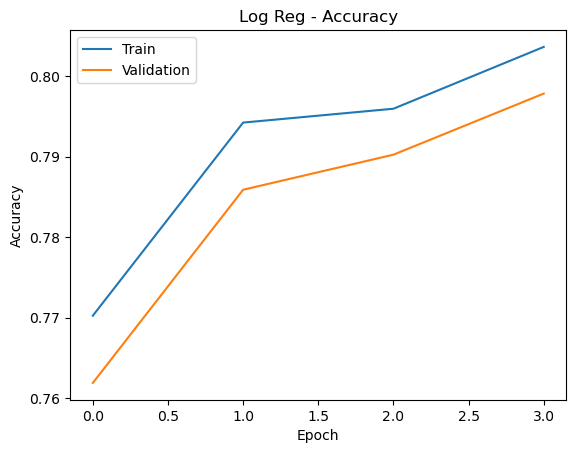

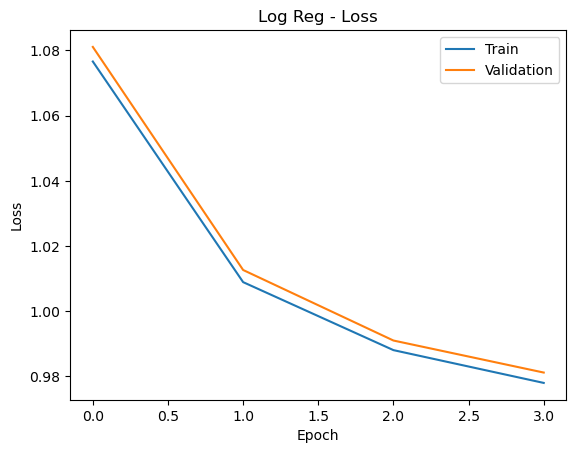

Test Accuracy: 0.7995
Modelo guardado em 'log_reg_model.pth'


In [20]:
# maior regularização e parar nas 4 epochs:
run_log_reg(lr=0.001, weight_decay=1e-1);

Epoch 01 | Train Loss: 1.3429  Acc: 0.5295 | Val Loss: 1.3468  Acc: 0.5209
Epoch 02 | Train Loss: 0.7004  Acc: 0.8790 | Val Loss: 0.7181  Acc: 0.8650
Epoch 03 | Train Loss: 0.4188  Acc: 0.9303 | Val Loss: 0.4468  Acc: 0.9110
Epoch 04 | Train Loss: 0.2941  Acc: 0.9493 | Val Loss: 0.3309  Acc: 0.9292
Epoch 05 | Train Loss: 0.2117  Acc: 0.9603 | Val Loss: 0.2566  Acc: 0.9375
Epoch 06 | Train Loss: 0.1596  Acc: 0.9696 | Val Loss: 0.2112  Acc: 0.9423


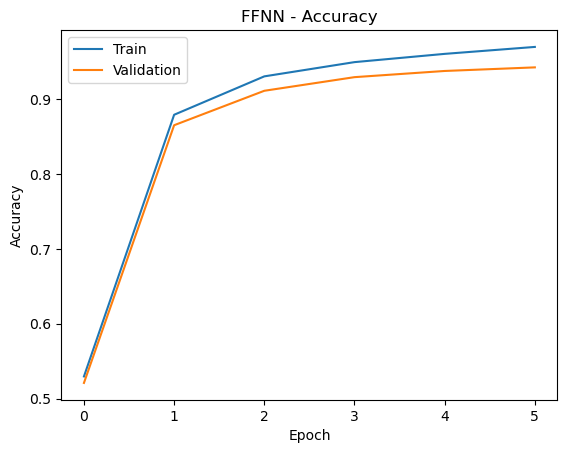

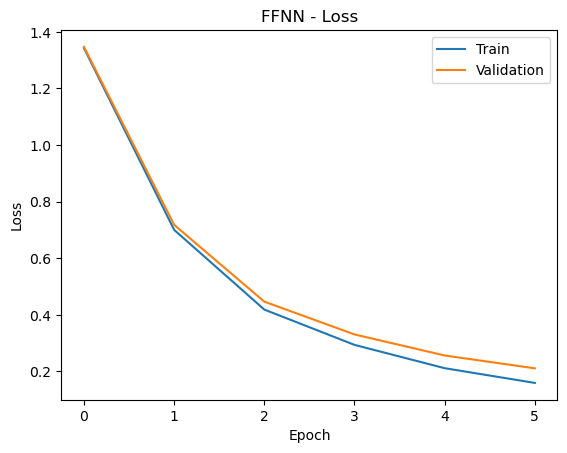

Test Accuracy: 0.9480
Modelo guardado em 'ffnn_model.pth'


In [33]:
# maior regularização e parar nas 6 epochs:
run_ffnn(topology=[256, 128],dropout=0.6,lr=0.0001, weight_decay=1e-3);

Epoch 01 | Train Loss: 1.5352  Acc: 0.4604 | Val Loss: 1.5366  Acc: 0.4565
Epoch 02 | Train Loss: 1.4140  Acc: 0.4381 | Val Loss: 1.4173  Acc: 0.4350
Epoch 03 | Train Loss: 1.2854  Acc: 0.5360 | Val Loss: 1.2912  Acc: 0.5253
Epoch 04 | Train Loss: 1.1647  Acc: 0.6542 | Val Loss: 1.1730  Acc: 0.6370
Epoch 05 | Train Loss: 1.0577  Acc: 0.7457 | Val Loss: 1.0684  Acc: 0.7220
Epoch 06 | Train Loss: 0.9663  Acc: 0.8038 | Val Loss: 0.9803  Acc: 0.7794
Epoch 07 | Train Loss: 0.8911  Acc: 0.8397 | Val Loss: 0.9072  Acc: 0.8164
Epoch 08 | Train Loss: 0.8281  Acc: 0.8614 | Val Loss: 0.8465  Acc: 0.8367
Epoch 09 | Train Loss: 0.7753  Acc: 0.8784 | Val Loss: 0.7960  Acc: 0.8538
Epoch 10 | Train Loss: 0.7309  Acc: 0.8883 | Val Loss: 0.7539  Acc: 0.8621
Epoch 11 | Train Loss: 0.6930  Acc: 0.8950 | Val Loss: 0.7179  Acc: 0.8678
Epoch 12 | Train Loss: 0.6603  Acc: 0.9028 | Val Loss: 0.6868  Acc: 0.8753
Epoch 13 | Train Loss: 0.6313  Acc: 0.9079 | Val Loss: 0.6597  Acc: 0.8792
Epoch 14 | Train Loss: 0.

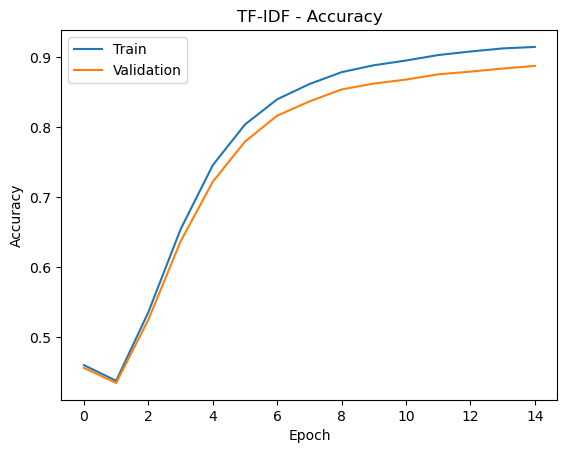

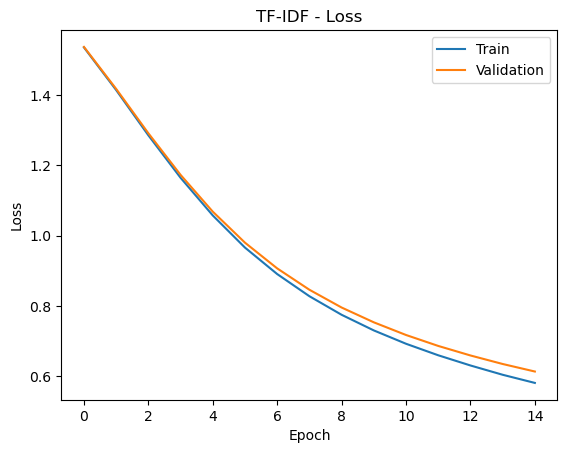

Test Accuracy: 0.8942
Modelo guardado em 'tfidf_model.pth'


In [35]:
run_tfidf(topology=[128], dropout=0.6, lr=0.0001, weight_decay=0.001,
early_stopping_patience=3);

## 12. Previsões em Dados de Exemplo

Carrega um modelo guardado e faz previsões num novo dataset com colunas `ID`, `Text`, `Label`.

In [36]:
def clean_text_light(text):
    text = str(text)
    text = unicodedata.normalize('NFKC', text)
    replacements = {
        '\u2018': "'", '\u2019': "'", '\u201c': '"', '\u201d': '"',
        '\u2013': '-', '\u2014': '-', '\u00a0': ' ',
    }
    for old, new in replacements.items():
        text = text.replace(old, new)
    text = re.sub(r'[\x00-\x08\x0b\x0c\x0e-\x1f\x7f]', ' ', text)
    text = re.sub(r'\r\n?', '\n', text)
    text = re.sub(r'\n{3,}', '\n\n', text)
    text = re.sub(r'[ \t]+', ' ', text)
    return text.strip()

def strip_json_edge_artifacts(text):
    text = str(text).strip()
    edge_chars = '"\'()[]{}'
    while text and text[0] in edge_chars:
        text = text[1:].lstrip()
    while text and text[-1] in edge_chars:
        text = text[:-1].rstrip()
    return text

In [38]:
####  O modelo escolhido para a submissão foi a FFNN, uma vez que depois de ser aplicada uma maior regularização os 
#     resultados melhoraram significativamente e consideramos ser o modelo que conseguiu generalizar melhor os dados.

# ou load_log_reg por load_ffnn, load_embed, load_lstm, etc. conforme o modelo treinado

# o modelo
model, word_index, max_words = load_ffnn("ffnn_model.pth")

# Carregar os dados novos 
dados_exemplo = pd.read_csv("dataset-exemplos.csv", sep=";")

# Limpeza 
dados_exemplo["Text"] = dados_exemplo["Text"].apply(clean_text_light)
dados_exemplo["Text"] = dados_exemplo["Text"].apply(strip_json_edge_artifacts)

# Previsões 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

previsoes = []
with torch.no_grad():
    for texto in dados_exemplo["Text"]:
        cleaned = clean_text(texto)
        x = vectorize_text(cleaned, word_index, max_words).unsqueeze(0).to(device)
        output = model(x)
        pred_idx = output.argmax(dim=1).item()
        previsoes.append(LABEL_NAMES[pred_idx])

dados_exemplo["Previsao"] = previsoes

# Accuracy
correct = (dados_exemplo["Label"] == dados_exemplo["Previsao"]).sum()
total   = len(dados_exemplo)
print(f"Accuracy: {correct/total:.4f} ({correct}/{total} corretos)")

# Resultados
print(dados_exemplo[["ID", "Label", "Previsao"]])

Modelo carregado de 'ffnn_model.pth'
Accuracy: 0.4560 (57/125 corretos)
         ID      Label   Previsao
0      D1-1      Human      Human
1      D1-2       Meta     OpenAI
2      D1-3     Google  Anthropic
3      D1-4       Meta  Anthropic
4      D1-5      Human     OpenAI
..      ...        ...        ...
120  D1-121     Google  Anthropic
121  D1-122     OpenAI  Anthropic
122  D1-123  Anthropic  Anthropic
123  D1-124      Human  Anthropic
124  D1-125       Meta  Anthropic

[125 rows x 3 columns]


### 12.1 Análise Detalhada por Classe

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print(classification_report(dados_exemplo["Label"], dados_exemplo["Previsao"]))

# Matriz de confusão
cm = confusion_matrix(dados_exemplo["Label"], dados_exemplo["Previsao"],
                      labels=[l for l in LABEL_NAMES if l in dados_exemplo["Label"].unique()])
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=[l for l in LABEL_NAMES if l in dados_exemplo["Label"].unique()],
            yticklabels=[l for l in LABEL_NAMES if l in dados_exemplo["Label"].unique()])
plt.title("Matriz de Confusão")
plt.ylabel("Real")
plt.xlabel("Previsto")
plt.tight_layout()
plt.show()

### 13. Criação da nova coluna de previsões nos dados de submissão:

In [46]:
# 1. Carregar o modelo 
model, word_index, max_words = load_ffnn("ffnn_model.pth")

# 2. Carregar o ficheiro 
df = pd.read_csv("subm1.csv", sep=";")
df.shape

# 3. Limpeza apenas para previsões (não altera o df original) 
textos_limpos = df["Text"].apply(clean_text_light).apply(strip_json_edge_artifacts)

# 4. Previsões 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

previsoes = []
with torch.no_grad():
    for texto in textos_limpos:
        cleaned = clean_text(texto)
        x = vectorize_text(cleaned, word_index, max_words).unsqueeze(0).to(device)
        output = model(x)
        pred_idx = output.argmax(dim=1).item()
        previsoes.append(LABEL_NAMES[pred_idx])

# 5. Adiciona coluna Labels ao df original (texto intacto) 
df["Labels"] = previsoes

# 6. Guarda o resultado 
df.to_csv("subm1_com_labels.csv", sep=";", index=False)
df.shape
print("Ficheiro guardado em 'subm1_com_labels.csv'")
print(df[["ID", "Labels"]].head(10))

Modelo carregado de 'ffnn_model.pth'
Ficheiro guardado em 'subm1_com_labels.csv'
      ID     Labels
0   D2-1     OpenAI
1   D2-2  Anthropic
2   D2-3  Anthropic
3   D2-4     OpenAI
4   D2-5      Human
5   D2-6     OpenAI
6   D2-7  Anthropic
7   D2-8  Anthropic
8   D2-9  Anthropic
9  D2-10      Human
